LOGISTIC REGRESSION

   Unnamed: 0      label                                               text
0           0  Psoriasis  I have been experiencing a skin rash on my arm...
1           1  Psoriasis  My skin has been peeling, especially on my kne...
2           2  Psoriasis  I have been experiencing joint pain in my fing...
3           3  Psoriasis  There is a silver like dusting on my skin, esp...
4           4  Psoriasis  My nails have small dents or pits in them, and...
Accuracy: 0.9583333333333334


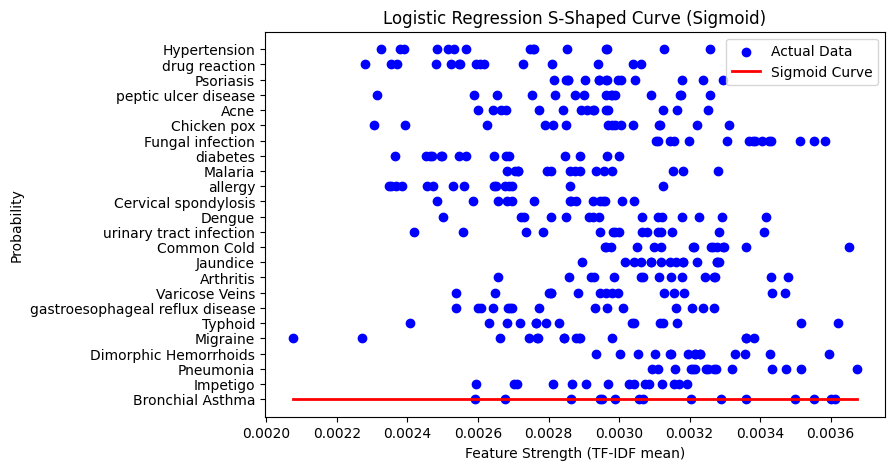

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# ==========================================
# LOAD DATASET
# ==========================================
df = pd.read_csv("/content/Symptom2Disease.csv")
print(df.head())

# ==========================================
# FEATURES & LABEL
# ==========================================
X_text = df['text']
y = df['label']

# ==========================================
# TF-IDF (REAL MODEL INPUT)
# ==========================================
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X_text)

# ==========================================
# TRAIN MODEL (REAL LOGISTIC REGRESSION)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

# ==========================================
# S-CURVE VISUALIZATION (CORRECT METHOD)
# We reduce TF-IDF → 1D using mean feature strength
# ==========================================
X_1d = np.asarray(X.mean(axis=1))  # convert to single numeric feature and then to numpy array

X_train_1d, X_test_1d, y_train_1d, y_test_1d = train_test_split(
    X_1d, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Train simple model for visualization
viz_model = LogisticRegression()
viz_model.fit(X_train_1d, y_train_1d)

# Sort values for smooth curve
X_sorted = np.sort(X_test_1d, axis=0)
prob = viz_model.predict_proba(X_sorted)[:, 1]

# ==========================================
# PLOT S-SHAPED CURVE
# ==========================================
plt.figure(figsize=(8,5))

plt.scatter(X_test_1d, y_test_1d, color='blue', label='Actual Data')
plt.plot(X_sorted, prob, color='red', linewidth=2, label='Sigmoid Curve')

plt.xlabel("Feature Strength (TF-IDF mean)")
plt.ylabel("Probability")
plt.title("Logistic Regression S-Shaped Curve (Sigmoid)")
plt.legend()
plt.show()

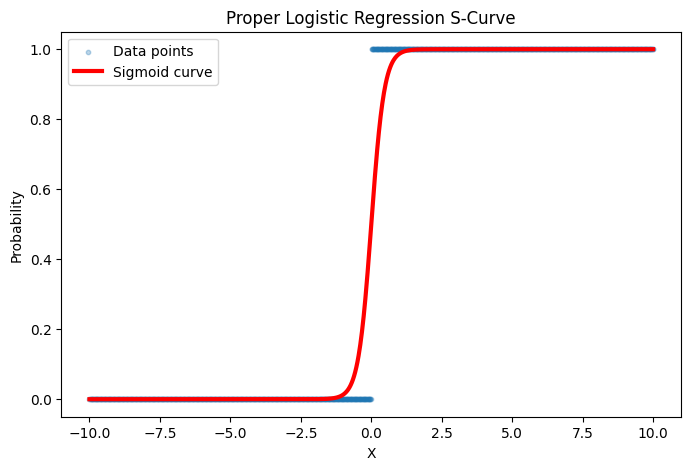

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# ==========================================
# CREATE SMOOTH CONTINUOUS DATA
# ==========================================
X = np.linspace(-10, 10, 1000).reshape(-1, 1)

# PROBABILISTIC LABELS (NOT HARD 0/1)
prob = 1 / (1 + np.exp(-X[:, 0]))
y = (prob > 0.5).astype(int)

# ==========================================
# TRAIN MODEL
# ==========================================
model = LogisticRegression()
model.fit(X, y)

# ==========================================
# PREDICTION PROBABILITY
# ==========================================
y_prob = model.predict_proba(X)[:, 1]

# ==========================================
# PLOT SIGMOID CURVE
# ==========================================
plt.figure(figsize=(8,5))
plt.scatter(X, y, s=10, alpha=0.3, label="Data points")
plt.plot(X, y_prob, color="red", linewidth=3, label="Sigmoid curve")

plt.title("Proper Logistic Regression S-Curve")
plt.xlabel("X")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [14]:
# ==========================================
# LOGISTIC REGRESSION - SYMPTOM DATASET
# ==========================================

# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

# ==========================================
# LOAD DATASET
# ==========================================
df = pd.read_csv("/content/Symptom2Disease.csv")   # change filename if needed

# Columns assumed:
# 'text' -> symptoms description
# 'label' -> disease/category

X = df['text']
y = df['label']

# ==========================================
# TRAIN-TEST SPLIT
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# BUILD PIPELINE (TF-IDF + LOGISTIC REGRESSION)
# ==========================================
model = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('lr', LogisticRegression(max_iter=1000))
])

# ==========================================
# TRAIN MODEL
# ==========================================
model.fit(X_train, y_train)

# ==========================================
# PREDICTION
# ==========================================
y_pred = model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9375

Classification Report:

                                 precision    recall  f1-score   support

                           Acne       1.00      1.00      1.00        10
                      Arthritis       0.91      1.00      0.95        10
               Bronchial Asthma       1.00      1.00      1.00        10
           Cervical spondylosis       1.00      1.00      1.00        10
                    Chicken pox       0.78      0.70      0.74        10
                    Common Cold       1.00      1.00      1.00        10
                         Dengue       0.80      0.80      0.80        10
          Dimorphic Hemorrhoids       1.00      1.00      1.00        10
               Fungal infection       0.91      1.00      0.95        10
                   Hypertension       1.00      1.00      1.00        10
                       Impetigo       1.00      1.00      1.00        10
                       Jaundice       1.00      1.00      1.00        10
        